In [1]:
# Imports
import jax
jax.config.update("jax_enable_x64", True)
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import time

from cd_dynamax import ContDiscreteNonlinearSSM
from jax import vmap, value_and_grad


Define the Lorenz 63 Drift Function


In [2]:
true_sigma = 10.0
true_rho = 28.0
true_beta = 8.0 / 3.0
def drift_l63(x, sigma=true_sigma, rho=true_rho, beta=true_beta):
    """Lorenz '63 drift function."""
    x1, x2, x3 = x
    dx1 = sigma * (x2 - x1)
    dx2 = x1 * (rho - x3) - x2
    dx3 = x1 * x2 - beta * x3
    return jnp.array([dx1, dx2, dx3])

true_drift = lambda x: drift_l63(x) # Correctly-Specified model
slightly_bad_drift = lambda x: drift_l63(x, sigma=11.0) # Slightly Mis-Specified model
very_bad_drift = lambda x: drift_l63(x, sigma=25.0, rho=15.0, beta=10.0) # Highly Mis-Specified model

In [3]:
# System dimensions
state_dim = 3 # Lorenz '63 has 3 state dimensions
emission_dim = 1 # Here we choose to observe only the first dimension
H = jnp.eye(emission_dim, state_dim)

# Noise parameters
diffusion_coeff_true = 1.0
emission_sd_true = 5.0
initial_state_sd_true = 30.0

# Create the SSM
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
from cd_dynamax import ContDiscreteNonlinearGaussianSSM
cdnlgssm = ContDiscreteNonlinearGaussianSSM(state_dim=state_dim, emission_dim=emission_dim)

# Build the true parameters
true_params = cdnlgssm.build_params(
    drift=true_drift,
    initial_mean=jnp.zeros(state_dim),
    initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
    diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
    emission_function=lambda x: H @ x,
    emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
)

# Build slightly bad parameters for comparison
slightly_bad_params = cdnlgssm.build_params(
    # Use mis-specified drift
    drift=slightly_bad_drift,
    # Keep other parameters the same
    initial_mean=jnp.zeros(state_dim),
    initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
    diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
    emission_function=lambda x: H @ x,
    emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
)

# Build very bad parameters
very_bad_params = cdnlgssm.build_params(
    # Use mis-specified drift
    drift=very_bad_drift,
    # Keep other parameters the same
    initial_mean=jnp.zeros(state_dim),
    initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
    diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
    emission_function=lambda x: H @ x,
    emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
)


Simulate data using true parameters

[make_t_emissions] Generated 1000 points from 0.0 to 100.0 with avg step ~0.1000
[make_t_emissions] Smallest time step = 0.000183
Sampling from SDE solver path: this may be an unnecessarily poor approximation if you're simulating from a linear SDE. It is an appropriate choice for non-linear SDEs.
Sampling from continuous-discrete non-linear Gaussian SSM path


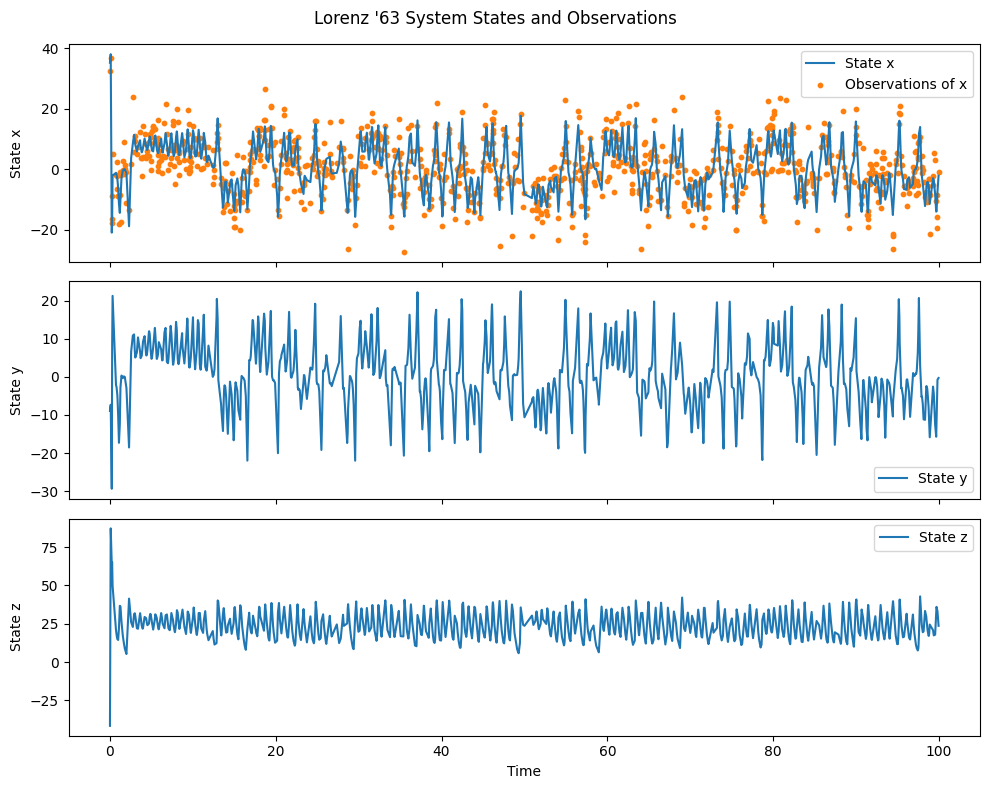

In [4]:
from cd_dynamax import make_key_sequence
from cd_dynamax.src.utils.demo_utils import sample_t_emissions

keys = make_key_sequence(0)
t_emissions = sample_t_emissions(start=0.0, stop=100.0, dt=0.1, regular=False, key=next(keys))

# Simulate data using true parameters (observed at times t_emissions)
# Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
states, emissions = cdnlgssm.sample(
    params=true_params,
    key=next(keys),
    num_timesteps=len(t_emissions),
    t_emissions=t_emissions,
    transition_type="path",
)

# Plot the results in a subplot with 3 rows, with observations overlaid in first emission_dims rows
fig, axs = plt.subplots(state_dim, 1, figsize=(10, 8), sharex=True)
state_labels = ['x', 'y', 'z']
for i in range(state_dim):
    axs[i].plot(t_emissions, states[:, i], label=f'State {state_labels[i]}', color='C0')
    if i < emission_dim:
        axs[i].scatter(t_emissions, emissions[:, i], label=f'Observations of {state_labels[i]}', color='C1', s=10)
    axs[i].legend()
    axs[i].set_ylabel(f'State {state_labels[i]}')
axs[-1].set_xlabel('Time')
plt.suptitle('Lorenz \'63 System States and Observations')
plt.tight_layout()
plt.show()

Now perform filtering over the observed emissions using EnKF. This produces filtered state estimates at the observation times, but also, crucially, computes an estimate of the log likelihood of the observed data under the model.

In [5]:
def filter_and_compute_loglik(params, title="True parameters", T=None):
    
    if T is None:
        T = len(emissions)

    emissions_to_use = emissions[:T]
    t_emissions_to_use = t_emissions[:T]
    states_to_use = states[:T]
    

    # Note that default SDE diffeqsolve settings solve using dfx.Heun() with dfx.ConstantStepSize() and dt0=0.01 step size.
    filtered = cdnlgssm.filter(
        params=params,
        emissions=emissions_to_use,
        t_emissions=t_emissions_to_use,
        key=next(keys),
        enkf_N_particles=100,
    )

    print(f"Log likelihood {title}:", float(filtered.marginal_loglik))

    # Plot a subfigure with state_dim rows showing true state, filtered mean and (optionally via shaded region) filtered stddev.
    # Also plot the observations in the first emission_dim rows.
    fig, axs = plt.subplots(state_dim, 1, figsize=(10, 8), sharex=True)
    for i in range(state_dim):
        axs[i].plot(t_emissions_to_use, states_to_use[:, i], label=f'True State {state_labels[i]}', color='C0')
        axs[i].plot(t_emissions_to_use, filtered.filtered_means[:, i], label=f'Filtered Mean {state_labels[i]}', color='C1')
        axs[i].fill_between(
            t_emissions_to_use.squeeze(),
            filtered.filtered_means[:, i] - 2 * jnp.sqrt(filtered.filtered_covariances[:, i, i]),
            filtered.filtered_means[:, i] + 2 * jnp.sqrt(filtered.filtered_covariances[:, i, i]),
            color='C1',
            alpha=0.3,
            label=f'Filtered ±2 Stddev {state_labels[i]}'
        )
        if i < emission_dim:
            axs[i].scatter(t_emissions_to_use, emissions_to_use[:, i], label=f'Observations of {state_labels[i]}', color='C2', s=10)
        axs[i].legend(loc='upper right')
        axs[i].set_ylabel(f'State {state_labels[i]}')
    axs[-1].set_xlabel('Time')
    plt.suptitle(title)
    plt.tight_layout()

    return filtered.marginal_loglik
        

Now we can compute the log likelihood at the true parameters, then at the mis-specified parameters. We will visualize the resulting filtering distributions as well to give intuitition for why the log likelihoods differ. 

The likelihood should decrease when the parameters get further from the truth---the true parameters should yield the highest log-likelihood. If they don't, then the finite-amount of noisy data is at likely play---those two models are not distinguishable given the data. This is typically why we use Bayesian methods to quantify uncertainty in parameter estimates.

CAVEAT: the likelihood approximation is stochastic and approximate.

Log likelihood Filtering Results at True Parameters: -326.16028554799766
Log likelihood Filtering Results at Slightly Bad Parameters: -326.8370719280746
Log likelihood Filtering Results at Very Bad Parameters: -895.7091001300375


Array(-895.70910013, dtype=float64)

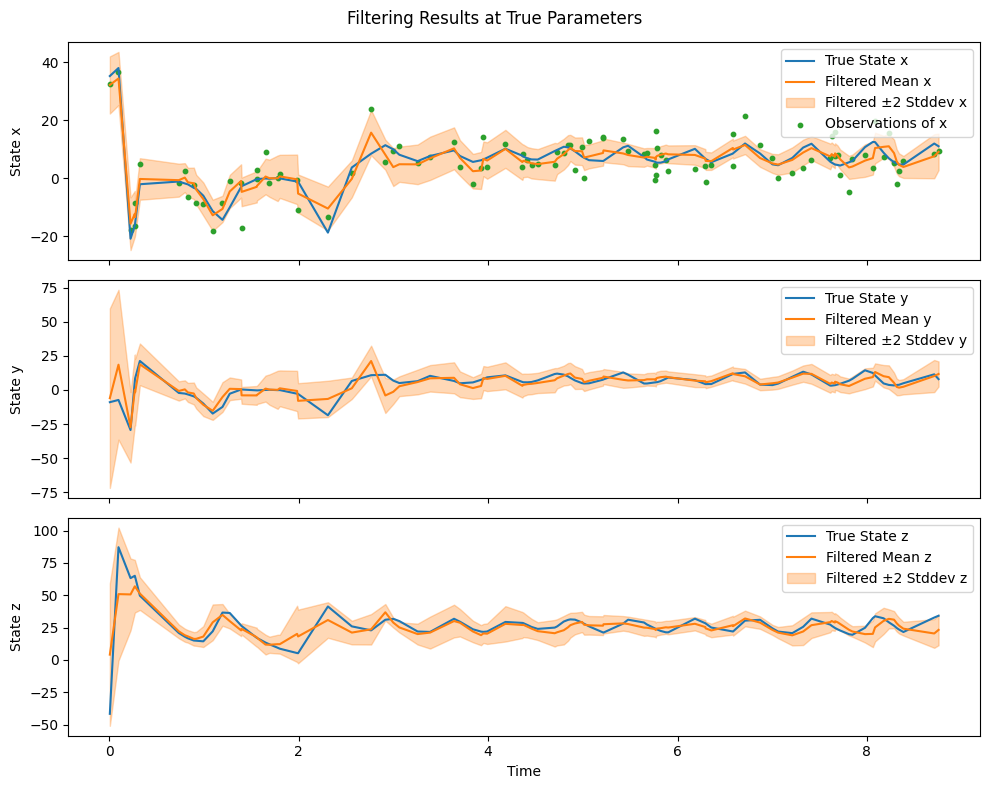

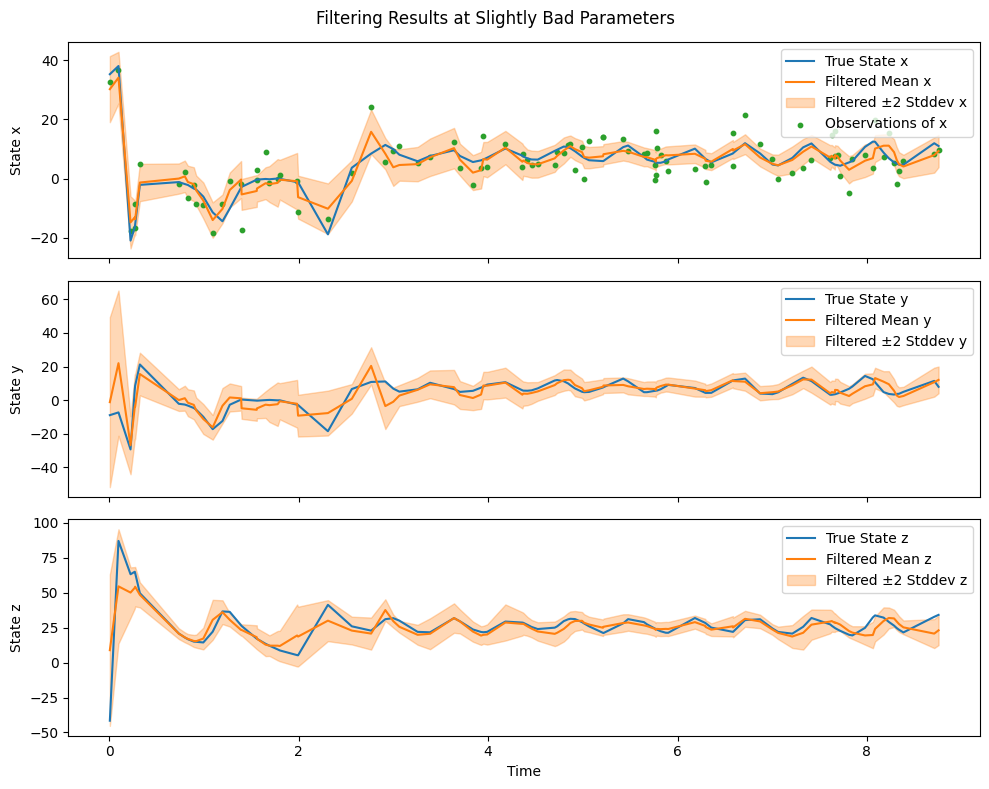

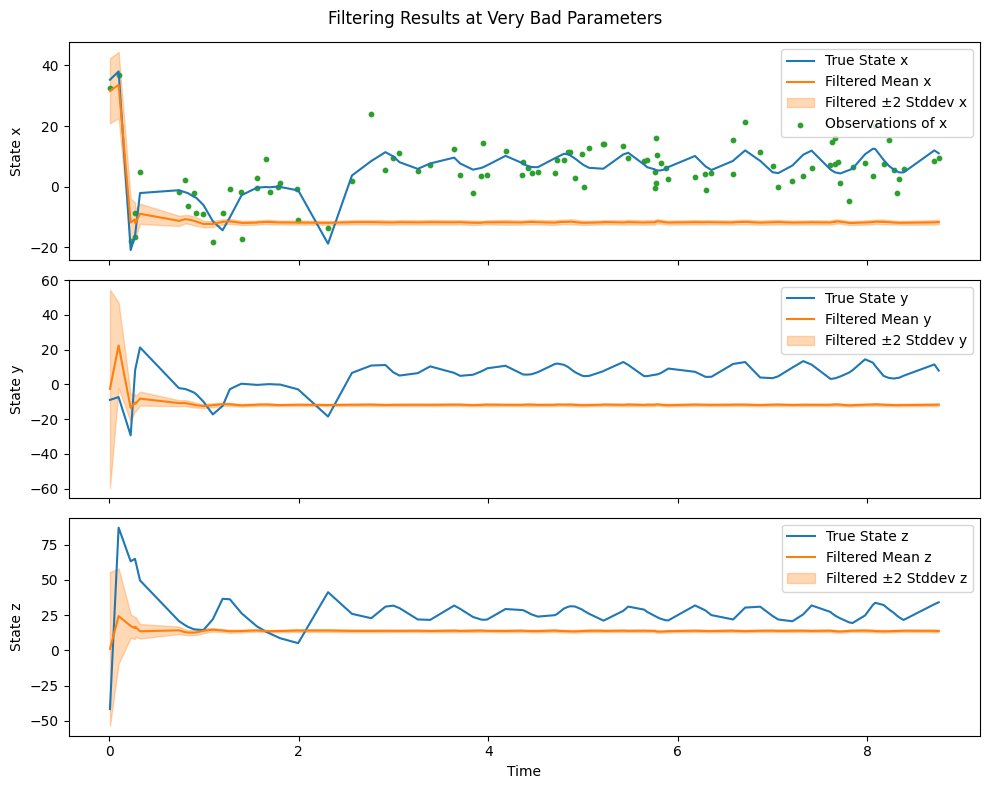

In [6]:
# Run for 10% of data for easy visualization and fast computation.
filter_and_compute_loglik(true_params, title="Filtering Results at True Parameters", T=len(emissions)//10)
filter_and_compute_loglik(slightly_bad_params, title="Filtering Results at Slightly Bad Parameters", T=len(emissions)//10)
filter_and_compute_loglik(very_bad_params, title="Filtering Results at Very Bad Parameters", T=len(emissions)//10)

Particle filtering with the CD-NLSSM (soft DPF)



In [7]:
# Build a CD-NLSSM instance and parameters matching the Gaussian model above
# The emission function must handle batches of particles; for a single state it reduces to H @ x.
def emission_fn(x, u=None, t=None):
    return x @ H.T if x.ndim > 1 else H @ x

cdnlssm = ContDiscreteNonlinearSSM(state_dim=state_dim, emission_dim=emission_dim)

true_params_pf = cdnlssm.build_params(
    drift=true_drift,
    initial_mean=jnp.zeros(state_dim),
    initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
    diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
    diffusion_cov=diffusion_coeff_true * jnp.eye(state_dim),
    emission_function=emission_fn,
    emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
)

slightly_bad_params_pf = cdnlssm.build_params(
    drift=slightly_bad_drift,
    initial_mean=jnp.zeros(state_dim),
    initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
    diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
    diffusion_cov=diffusion_coeff_true * jnp.eye(state_dim),
    emission_function=emission_fn,
    emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
)

very_bad_params_pf = cdnlssm.build_params(
    drift=very_bad_drift,
    initial_mean=jnp.zeros(state_dim),
    initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
    diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
    diffusion_cov=diffusion_coeff_true * jnp.eye(state_dim),
    emission_function=emission_fn,
    emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
)

keys_pf = make_key_sequence(123)



In [8]:
def dpf_filter_and_compute_loglik(params, title="DPF parameters", T=None, N_particles=200):
    if T is None:
        T = len(emissions)

    emissions_to_use = emissions[:T]
    t_emissions_to_use = t_emissions[:T]
    states_to_use = states[:T]

    filtered = cdnlssm.filter(
        params=params,
        emissions=emissions_to_use,
        t_emissions=t_emissions_to_use,
        key=next(keys_pf),
        N_particles=N_particles,
        warn=False,
    )

    print(f"DPF log likelihood {title}:", float(filtered.marginal_loglik))

    fig, axs = plt.subplots(state_dim, 1, figsize=(10, 8), sharex=True)
    for i in range(state_dim):
        axs[i].plot(t_emissions_to_use, states_to_use[:, i], label=f'True State {state_labels[i]}', color='C0')
        axs[i].plot(t_emissions_to_use, filtered.filtered_means[:, i], label=f'Filtered Mean {state_labels[i]}', color='C3')
        axs[i].fill_between(
            t_emissions_to_use.squeeze(),
            filtered.filtered_means[:, i] - 2 * jnp.sqrt(filtered.filtered_covariances[:, i, i]),
            filtered.filtered_means[:, i] + 2 * jnp.sqrt(filtered.filtered_covariances[:, i, i]),
            color='C3',
            alpha=0.25,
            label=f'Filtered ±2 Stddev {state_labels[i]}'
        )
        if i < emission_dim:
            axs[i].scatter(t_emissions_to_use, emissions_to_use[:, i], label=f'Observations of {state_labels[i]}', color='C2', s=10)
        axs[i].legend(loc='upper right')
        axs[i].set_ylabel(f'State {state_labels[i]}')
    axs[-1].set_xlabel('Time')
    plt.suptitle(title)
    plt.tight_layout()

    return filtered.marginal_loglik



DPF log likelihood DPF at True Parameters: -326.2178544896651
DPF at True Parameters time: 1.54 seconds
DPF log likelihood DPF at Slightly Bad Parameters: -322.14137305398106
DPF at Slightly Bad Parameters time: 1.16 seconds
DPF log likelihood DPF at Very Bad Parameters: -891.997583231311
DPF at Very Bad Parameters time: 1.31 seconds


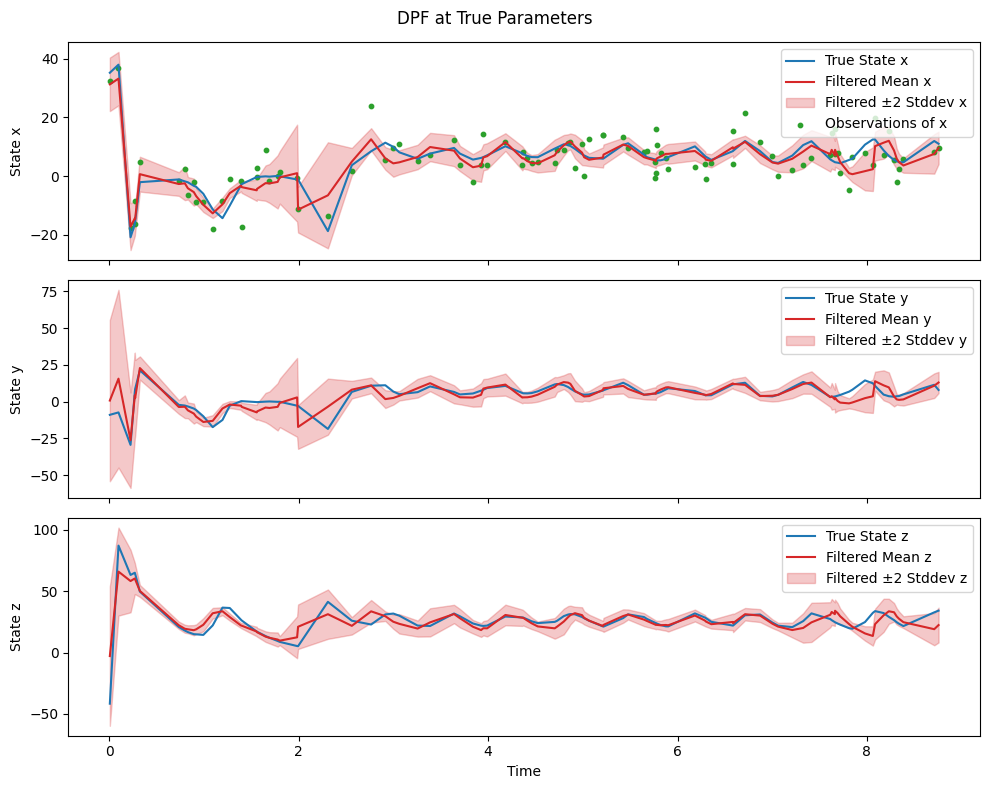

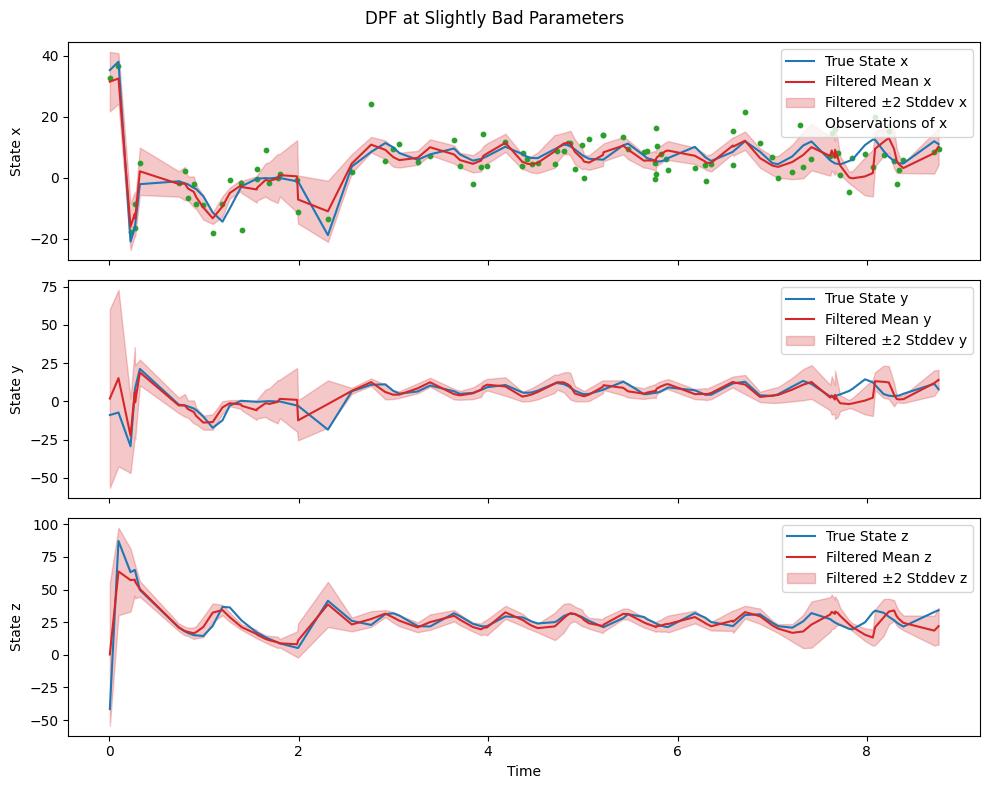

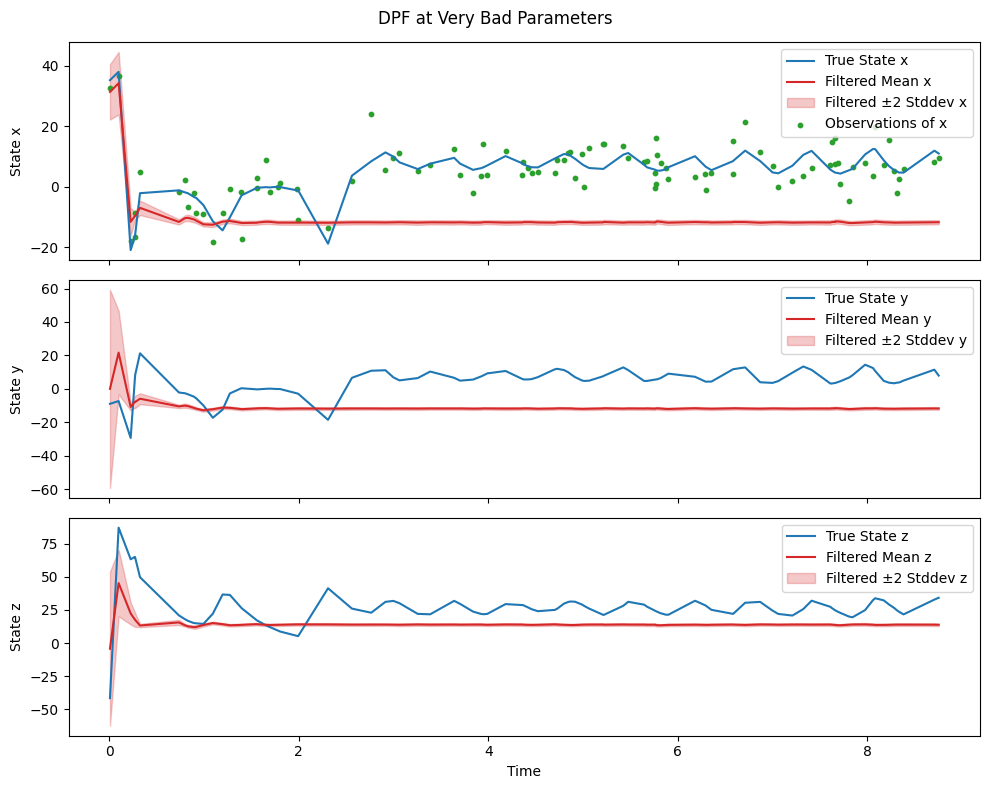

In [9]:
# Run particle filtering on a subset for speed
T_small = len(emissions) // 10

t_start = time.time()
dpf_filter_and_compute_loglik(
    true_params_pf,
    title="DPF at True Parameters",
    T=T_small,
    N_particles=1_000,
)
t_end = time.time()
print(f"DPF at True Parameters time: {t_end - t_start:.2f} seconds")

t_start = time.time()
dpf_filter_and_compute_loglik(
    slightly_bad_params_pf,
    title="DPF at Slightly Bad Parameters",
    T=T_small,
    N_particles=1_000,
)
t_end = time.time()
print(f"DPF at Slightly Bad Parameters time: {t_end - t_start:.2f} seconds")

t_start = time.time()
dpf_filter_and_compute_loglik(
    very_bad_params_pf,
    title="DPF at Very Bad Parameters",
    T=T_small,
    N_particles=1_000,
)
t_end = time.time()
print(f"DPF at Very Bad Parameters time: {t_end - t_start:.2f} seconds")



Now, let's sweep over Rho (holding sigma and beta fixed at true values) to see how the log likelihood varies with this parameter. We should see a peak around the true value of Rho=28.0, but we know that the amount of data is limited and the likelihood is approximate, so we may not see this exactly. If you want to see an unbiased peak, try increasing the amount of data (T) and number of particles.


In [10]:
def compute_likelihood_at_rho(rho_value, T=None, N_particles=100):
    
    if T is None:
        T = len(emissions)
    
    emissions_to_use = emissions[:T]
    t_emissions_to_use = t_emissions[:T]
    
    # Build parameters with given sigma value
    params = cdnlgssm.build_params(
        # Use drift with specified sigma
        drift=lambda x: drift_l63(x, rho=rho_value),
        # all other parameters same as true
        initial_mean=jnp.zeros(state_dim),
        initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
        diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
        emission_function=lambda x: H @ x,
        emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
    )

    # Run filtering to compute log likelihood
    filtered = cdnlgssm.filter(
        params=params,
        emissions=emissions_to_use,
        t_emissions=t_emissions_to_use,
        key=next(keys), # if you comment this out, you'll get deterministic results (the EnKF will always be seeded with jr.PRNGKey(0))
        enkf_N_particles=N_particles,
        warn=False,
    )
    
    return filtered.marginal_loglik

In [11]:
import time
from jax import vmap, value_and_grad
# jax.config.update("jax_enable_x64", True) # might help with numerical stability

def rho_sweep_experiment(T=None, N_particles=100, do_slow_loops=False):
    if T is None:
        T = len(emissions)

    def _compute_likelihood_at_rho(rho):
        return compute_likelihood_at_rho(rho, T=T, N_particles=N_particles)

    rho_values = jnp.linspace(10.0, 50.0, 20)

    # ----------------------------------------------------------
    # vmap over both values and gradients
    # ----------------------------------------------------------
    print("Computing log-likelihoods and gradients (value_and_grad, vmap)...")
    val_and_grad_fn = value_and_grad(_compute_likelihood_at_rho)
    start_time = time.time()
    vals, grads = vmap(val_and_grad_fn)(rho_values)
    vmap_time = time.time() - start_time
    print(f"vmap time: {vmap_time:.2f} seconds")

    # ----------------------------------------------------------
    # Optional slower baselines
    # ----------------------------------------------------------
    if do_slow_loops:
        vals_loop, grads_loop = [], []
        start_time = time.time()
        for rho in rho_values:
            val, grad_val = val_and_grad_fn(rho)
            vals_loop.append(val)
            grads_loop.append(grad_val)
        vals_loop, grads_loop = jnp.array(vals_loop), jnp.array(grads_loop)
        loop_time = time.time() - start_time
        print(f"For-loop time: {loop_time:.2f} seconds")

        from jax import lax
        def scan_step(carry, rho):
            val, grad_val = val_and_grad_fn(rho)
            return carry, (val, grad_val)
        start_time = time.time()
        _, (vals_scan, grads_scan) = lax.scan(scan_step, None, rho_values)
        scan_time = time.time() - start_time
        print(f"lax.scan time: {scan_time:.2f} seconds")

    # ----------------------------------------------------------
    # Plot value + gradient
    # ----------------------------------------------------------
    fig, axs = plt.subplots(2, 1, figsize=(10, 10))

    # Log-likelihood
    axs[0].plot(rho_values, vals, label='vmap', marker='o')
    if do_slow_loops:
        axs[0].plot(rho_values, vals_loop, label='for-loop', marker='x')
        axs[0].plot(rho_values, vals_scan, label='lax.scan', marker='s')
    axs[0].axvline(true_rho, color='k', linestyle=':', label='True Rho')
    axs[0].set_xlabel('Rho Value')
    axs[0].set_ylabel('Log Likelihood')
    axs[0].set_title(f'Log Likelihood vs Rho (T={T}, N={N_particles})')
    axs[0].legend()

    # Gradient
    axs[1].plot(rho_values, grads, label='vmap grad', marker='o')
    if do_slow_loops:
        axs[1].plot(rho_values, grads_loop, label='for-loop grad', marker='x')
        axs[1].plot(rho_values, grads_scan, label='lax.scan grad', marker='s')
    axs[1].axhline(0.0, color='gray', linestyle='--')
    axs[1].axvline(true_rho, color='k', linestyle=':')
    axs[1].set_xlabel('Rho Value')
    axs[1].set_ylabel('∂(Log Likelihood)/∂Rho')
    axs[1].set_title('Gradient of Log Likelihood wrt Rho')
    axs[1].set_yscale('symlog')
    
    axs[1].legend()

    plt.tight_layout()
    plt.show()


Computing log-likelihoods and gradients (value_and_grad, vmap)...
vmap time: 39.76 seconds


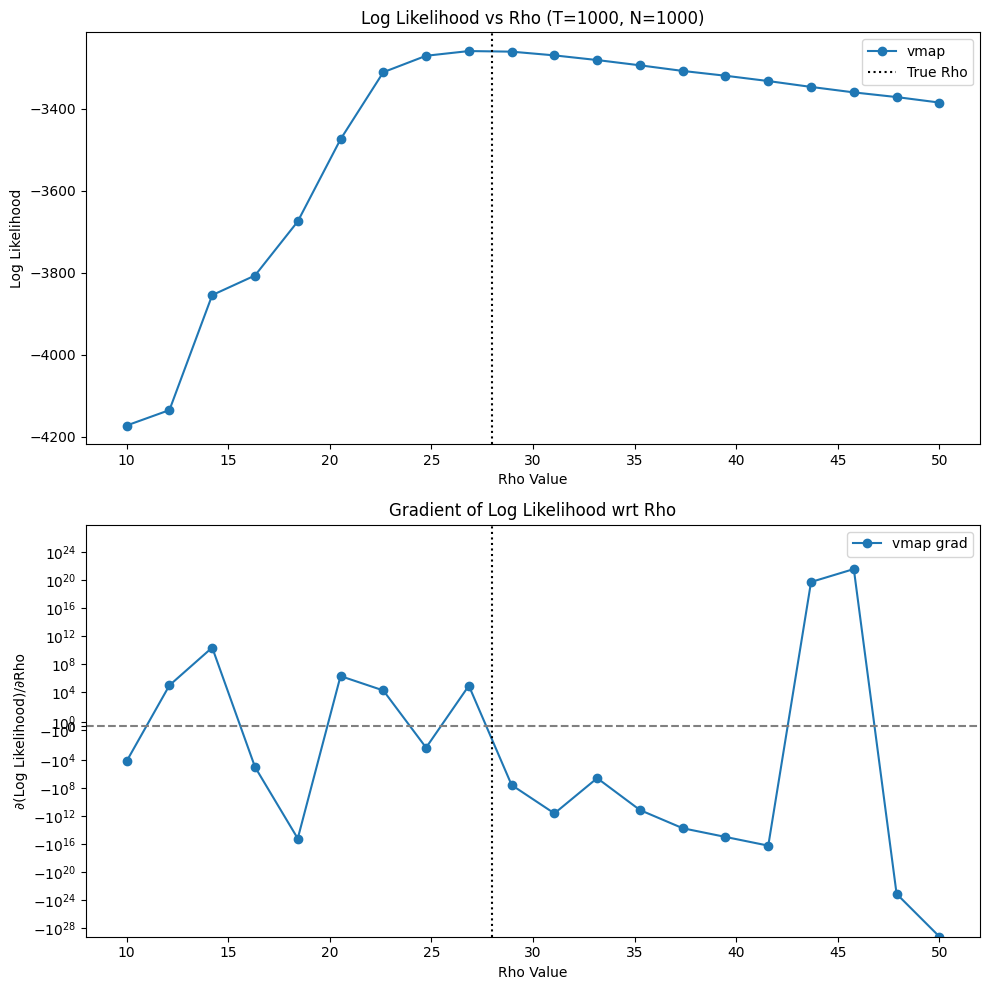

In [12]:
# Run sweep experiment with all data
rho_sweep_experiment(T=len(emissions), N_particles=1_000)

Computing log-likelihoods and gradients (value_and_grad, vmap)...
vmap time: 3.62 seconds


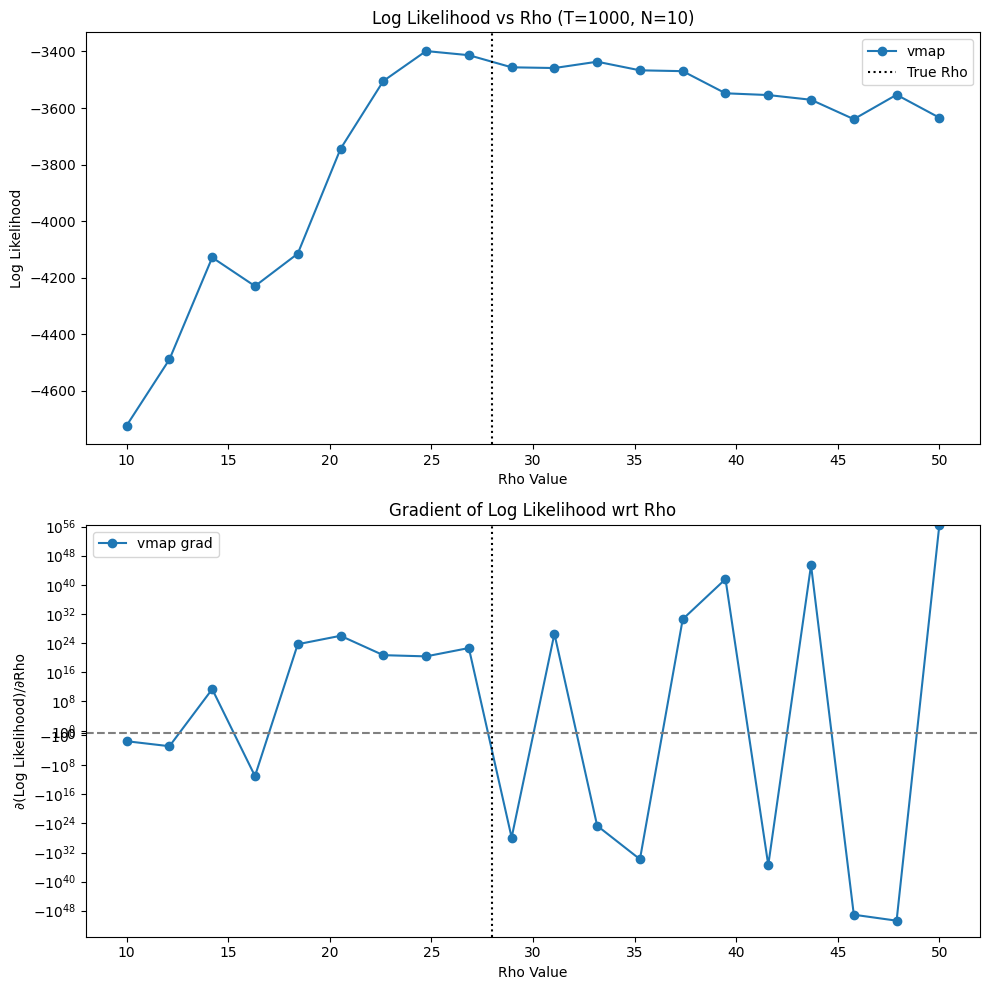

In [13]:
# Run sweep experiment with all data but few particles (bad approximation). Notice that it is jagged, and does not peak at the true value. This is due to high variance in the likelihood estimate with few particles.
rho_sweep_experiment(T=len(emissions), N_particles=10)

Computing log-likelihoods and gradients (value_and_grad, vmap)...
vmap time: 3.44 seconds
For-loop time: 56.46 seconds
lax.scan time: 5.27 seconds


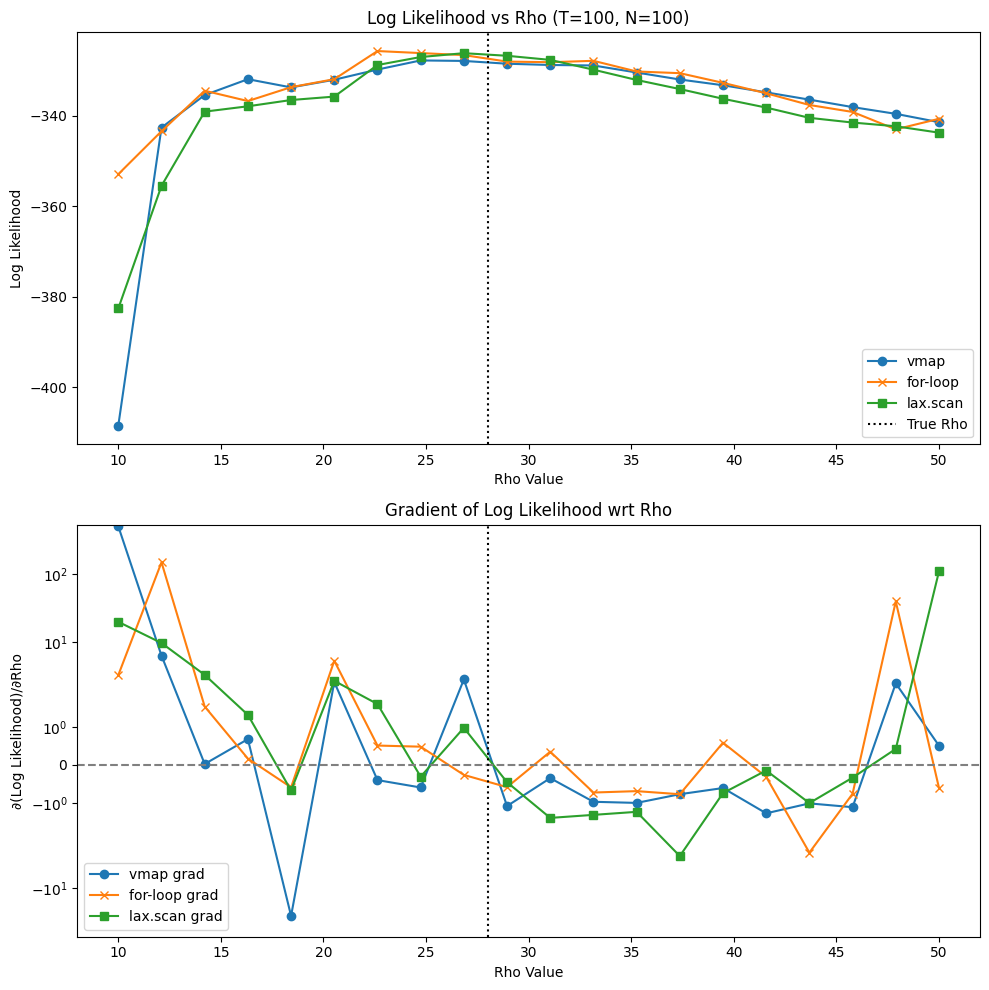

In [14]:
# Run sweep experiment with 10% of data. "Do slow loops" to see timing comparison between vmap, for-loop, and lax.scan.
# Here, we see that the likelihood peaks near the true value, but it is very flat in that region---that is due to limited data. 100 particles is likely sufficient to get a good approximation here.
rho_sweep_experiment(T=len(emissions)//10, N_particles=100, do_slow_loops=True)

Computing log-likelihoods and gradients (value_and_grad, vmap)...
vmap time: 2.88 seconds


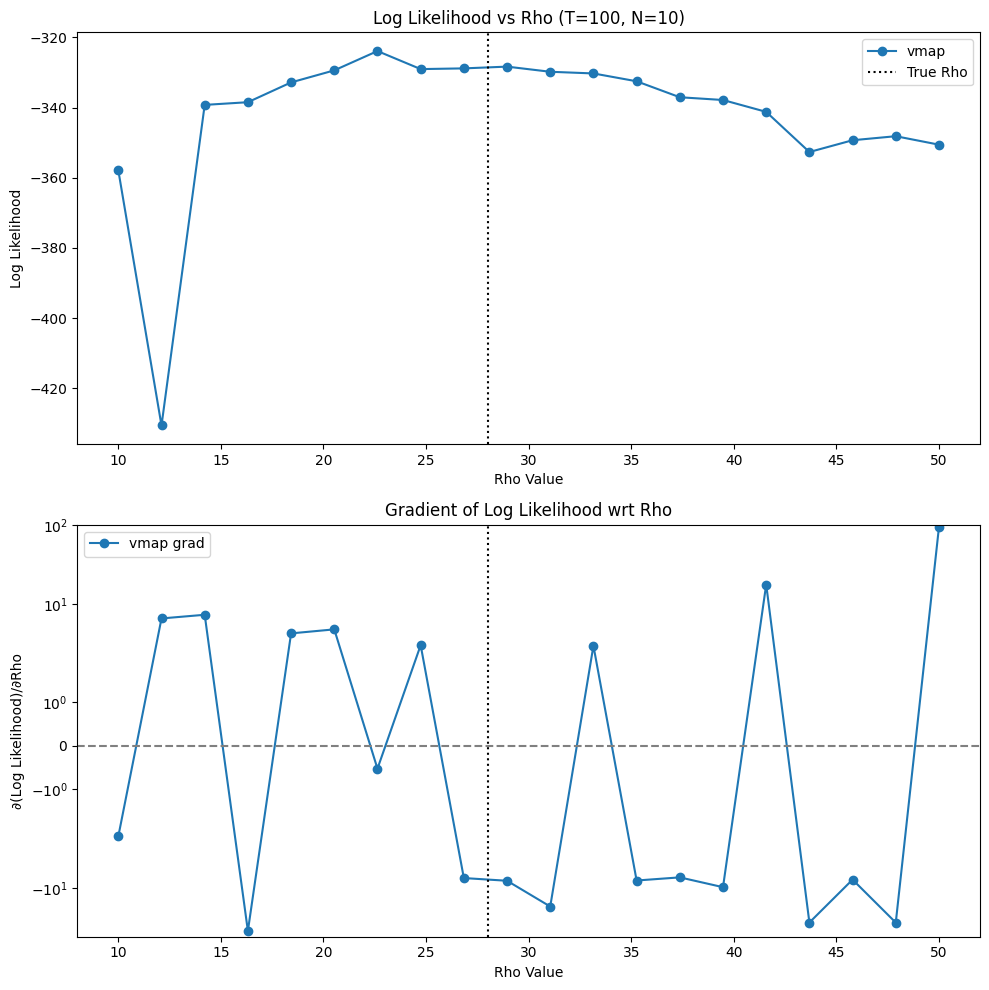

In [15]:
# Run sweep experiment with 10% of data and few particles.
# Now with small data and few particles, the likelihood is very noisy and also does not peak exactly at the true value (due to both limited data and high variance in the likelihood estimate).
# This is the noisiest of the experiments, and you can imagine that using such a likelihood could make parameter estimation / uncertainty quantification quite difficult! e.g., it introduces a spurious multimodality.
rho_sweep_experiment(T=len(emissions)//10, N_particles=10)

In [16]:
def compute_dpf_likelihood_at_rho(rho_value, T=None, N_particles=200, key=None):
    if T is None:
        T = len(emissions)

    emissions_to_use = emissions[:T]
    t_emissions_to_use = t_emissions[:T]

    params = cdnlssm.build_params(
        drift=lambda x: drift_l63(x, rho=rho_value),
        initial_mean=jnp.zeros(state_dim),
        initial_cov=(initial_state_sd_true**2) * jnp.eye(state_dim),
        diffusion_coeff=diffusion_coeff_true * jnp.eye(state_dim),
        diffusion_cov=diffusion_coeff_true * jnp.eye(state_dim),
        emission_function=emission_fn,
        emission_cov=(emission_sd_true**2) * jnp.eye(emission_dim),
    )

    use_key = key if key is not None else next(keys_pf)
    filtered = cdnlssm.filter(
        params=params,
        emissions=emissions_to_use,
        t_emissions=t_emissions_to_use,
        key=use_key,
        N_particles=N_particles,
        warn=False,
    )
    return filtered.marginal_loglik


def rho_sweep_experiment_dpf(T=None, N_particles=200):
    if T is None:
        T = len(emissions)

    rho_values = jnp.linspace(10.0, 50.0, 20)

    # Use the same random seed across all rho values (common random numbers).
    key_sweep = next(keys_pf)
    keys_sweep = jnp.broadcast_to(key_sweep, (rho_values.shape[0],) + key_sweep.shape)

    def _lik(rho, key):
        return compute_dpf_likelihood_at_rho(rho, T=T, N_particles=N_particles, key=key)

    val_and_grad_fn = value_and_grad(_lik)
    vals, grads = vmap(val_and_grad_fn)(rho_values, keys_sweep)

    fig, axs = plt.subplots(2, 1, figsize=(10, 8))
    axs[0].plot(rho_values, vals, label='DPF', marker='o')
    axs[0].axvline(true_rho, color='k', linestyle=':', label='True Rho')
    axs[0].set_xlabel('Rho Value')
    axs[0].set_ylabel('Log Likelihood (DPF)')
    axs[0].set_title(f'DPF Log Likelihood vs Rho (T={T}, N={N_particles})')
    axs[0].legend()

    axs[1].plot(rho_values, grads, label='DPF grad', marker='o')
    axs[1].axhline(0.0, color='gray', linestyle='--')
    axs[1].axvline(true_rho, color='k', linestyle=':')
    axs[1].set_xlabel('Rho Value')
    axs[1].set_ylabel('∂(Log Likelihood)/∂Rho (DPF)')
    axs[1].set_yscale('symlog')
    axs[1].legend()

    plt.tight_layout()

    return rho_values, vals, grads



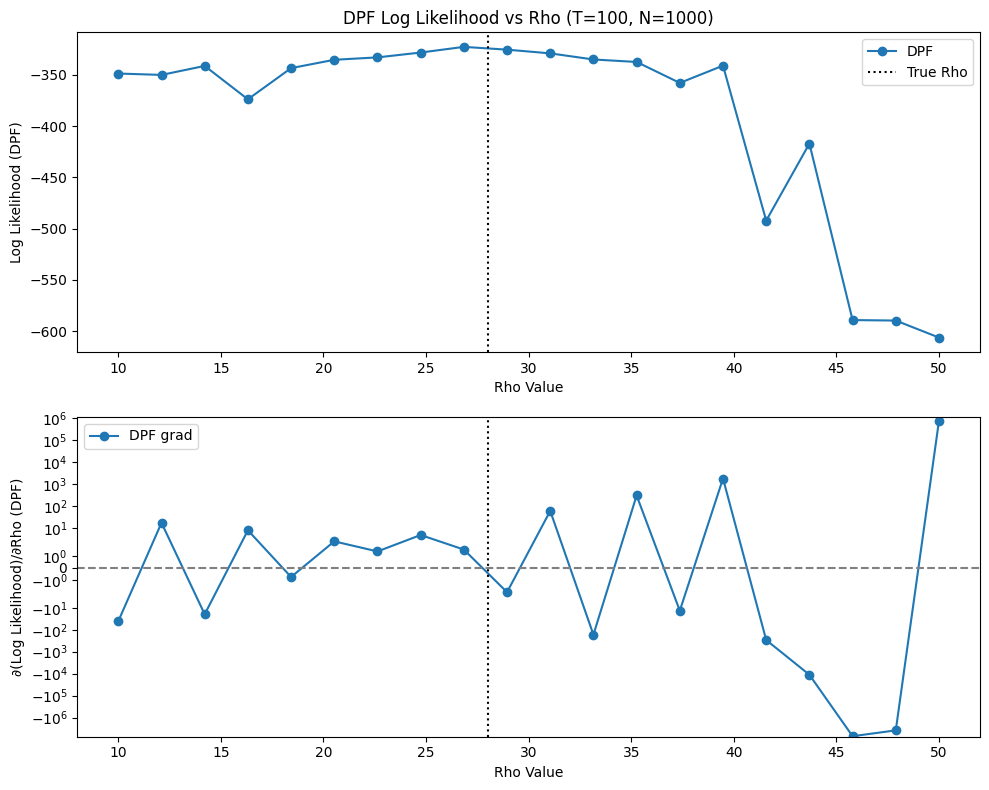

In [17]:
# DPF rho sweep on 10% of the data for speed
rho_values_dpf, vals_dpf, grads_dpf = rho_sweep_experiment_dpf(T=len(emissions)//10, N_particles=1_000)

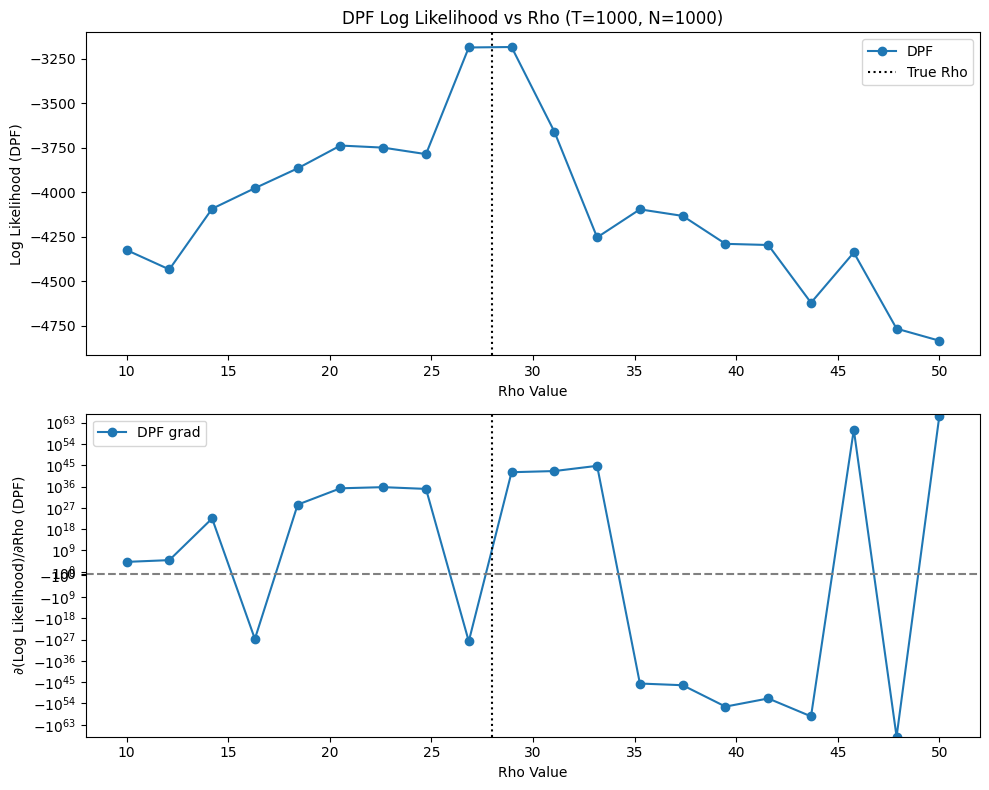

In [18]:
# DPF rho sweep on all data
rho_values_dpf, vals_dpf, grads_dpf = rho_sweep_experiment_dpf(
    T=len(emissions), N_particles=1_000
)